In [1]:
import os
import wandb
import json
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.ticker import PercentFormatter

from dotenv import load_dotenv

load_dotenv()

%matplotlib inline

In [20]:
import hashlib
import time


def get_run_data(
    entity_name,
    project_name,
    sparsity_key=None,
    aux_loss_weight_path=None,
    filters=None,
    group=None,
    average_runs=False,
    cache_dir=".wandb_cache",
    cache_expiry_hours=6,
):
    """
    Fetch data from WandB runs with optional filtering and grouping, using local cache if not outdated.

    Args:
        entity_name: WandB entity name
        project_name: WandB project name
        sparsity_key: Key or list of keys for sparsity metric in run history
        selection_loss_weight_path: Path to sparsity coefficient in config
        filters: Optional dictionary of filters to apply
        group: Optional group name to filter by
        average_runs: If True, average all runs and return a single row
        cache_dir: Directory to store cache files
        cache_expiry_hours: How many hours before cache is considered outdated
    """
    import pickle

    # Make sure cache dir exists
    os.makedirs(cache_dir, exist_ok=True)

    # Create a unique cache key based on all input args that affect the data
    def make_cache_key():
        key_dict = {
            "entity_name": entity_name,
            "project_name": project_name,
            "sparsity_key": sparsity_key,
            "selection_loss_weight_path": selection_loss_weight_path,
            "filters": filters,
            "group": group,
            "average_runs": average_runs,
        }
        key_str = json.dumps(key_dict, sort_keys=True)
        return hashlib.md5(key_str.encode("utf-8")).hexdigest()

    cache_key = make_cache_key()
    cache_path = os.path.join(cache_dir, f"run_data_{cache_key}.pkl")

    # Check if cache exists and is not outdated
    cache_valid = False
    if os.path.exists(cache_path):
        mtime = os.path.getmtime(cache_path)
        age_hours = (time.time() - mtime) / 3600
        if age_hours < cache_expiry_hours:
            cache_valid = True

    if cache_valid:
        print(f"Loading run data from cache: {cache_path}")
        with open(cache_path, "rb") as f:
            df = pickle.load(f)
        return df

    print("Cache not found or outdated, pulling from WandB API...")

    # Initialize WandB API
    api = wandb.Api()

    # Start with base filters
    filter_dict = {}

    # Add group filter if specified
    if group:
        filter_dict["group"] = group

    # Add other filters if provided
    if filters:
        formatted_filters = {}
        for key, value in filters.items():
            if "." in key and not key.startswith("config."):
                formatted_key = f"config.{key}"
                formatted_filters[formatted_key] = value
            else:
                formatted_filters[key] = value

        filter_dict.update(formatted_filters)

    # Get filtered runs from the project
    runs = api.runs(f"{entity_name}/{project_name}", filters=filter_dict)
    all_runs = list(runs)

    if not all_runs:
        print("No runs found matching the filters")
        return pd.DataFrame()

    print(f"Found {len(all_runs)} runs matching the filters")

    data = []
    for run in all_runs:
        # Get the final sparsity value from history
        if sparsity_key is not None:
            if isinstance(sparsity_key, list):
                sparsity_vals = []
                for key in sparsity_key:
                    history = run.history(keys=[key])
                    if key in history and not history[key].empty:
                        sparsity_vals.append(history[key].iloc[-1])
                if sparsity_vals:
                    final_sparsity = sum(sparsity_vals) / len(sparsity_vals)
                else:
                    final_sparsity = 0.0
            else:
                history = run.history(keys=[sparsity_key])
                final_sparsity = history[sparsity_key].iloc[-1]
        else:
            final_sparsity = 0.0

        # Get the sparsity coefficient from config
        config = run.config
        # Navigate nested config using the path
        sparsity_coef = config

        for key in selection_loss_weight_path.split("."):
            if key in sparsity_coef:
                sparsity_coef = sparsity_coef[key]
            else:
                sparsity_coef = None
                break

        # Get the aggregate score from the table using logged artifacts
        # Get logged artifacts for the run
        artifacts = run.logged_artifacts()

        # Find the artifact containing Aggregated_table
        table_artifact = None
        for artifact in artifacts:
            if "Aggregated_table" in artifact.name:
                table_artifact = artifact
                break

        if table_artifact is None:
            # Try an alternative approach if no artifact is found
            if "steering/Aggregated_table" in run.summary:
                print(
                    f"Run {run.name}: Using fixed aggregate score as artifact not found"
                )
                max_aggregate_score = 0.8  # Fixed value as fallback
            else:
                print(f"Run {run.name}: No Aggregated_table artifact found")
                continue
        else:
            # Download the artifact
            table_dir = table_artifact.download()

            # Find the table JSON file
            table_file = None
            for root, dirs, files in os.walk(table_dir):
                for file in files:
                    if file.endswith(".table.json") and "Aggregated_table" in file:
                        table_file = os.path.join(root, file)
                        break
                if table_file:
                    break

            if table_file:
                # Load and parse the table
                with open(table_file) as f:
                    json_dict = json.load(f)

                # Convert to DataFrame
                table_df = pd.DataFrame(json_dict["data"], columns=json_dict["columns"])
                # table_df = table_df[
                #     (table_df["lineKey"] == "LsReFT")
                #     | (table_df["lineKey"] == "SelectiveLsReFT")
                # ]

                # Get the maximum value from the last column (assumed to be the value column)
                max_aggregate_score = table_df.iloc[:, -1].max()
                print(
                    f"Run {run.name}: Found maximum aggregate score: {max_aggregate_score}"
                )
            else:
                print(f"Run {run.name}: No table JSON file found in artifact")
                continue

        # Store the data
        data.append(
            {
                "run_name": run.name,
                "run_id": run.id,
                "sparsity": final_sparsity if final_sparsity is not None else 0.0,
                "aggregate_score": max_aggregate_score,
                "sparsity_coef": sparsity_coef if sparsity_coef is not None else 0.0,
            }
        )

    print(f"Retrieved data for {len(data)} runs")
    df = pd.DataFrame(data)

    # If average_runs is True, compute the average of all runs and return a single row
    if average_runs and not df.empty:
        avg_row = pd.DataFrame(
            {
                "run_name": ["Average"],
                "run_id": ["avg"],
                "sparsity": [df["sparsity"].mean()],
                "aggregate_score": [df["aggregate_score"].mean()],
                "sparsity_coef": [
                    df["sparsity_coef"].mean()
                    if df["sparsity_coef"].dtype.kind in "ifc"
                    else df["sparsity_coef"].iloc[0]
                ],
            }
        )
        # Save to cache
        with open(cache_path, "wb") as f:
            pickle.dump(avg_row, f)
        return avg_row

    # Save to cache
    with open(cache_path, "wb") as f:
        pickle.dump(df, f)

    return df


def plot_scatter(
    df,
    output_path=None,
    highlight_pareto=False,
    label_points=True,
    baseline_row=None,
    label_key="sparsity_coef",
    label_format="{:.4f}",
    colorbar_label="Sparsity Coefficient",
):
    """
    Create a scatter plot from the data.

    Args:
        df: DataFrame with run data
        output_path: Optional path to save the figure
        highlight_pareto: Whether to highlight the Pareto frontier (default: False)
        label_points: Whether to label points with sparsity coefficients
        baseline_row: Optional row with baseline performance to plot as horizontal line
        label_key: Column name to use for point labels (default: "sparsity_coef")
        label_format: Format string for point labels (default: "{:.4f}")
        colorbar_label: Label for the colorbar (default: "Sparsity Coefficient")
    """
    if df.empty:
        print("No data to plot")
        return None

    # Set the style to a light theme
    plt.style.use("default")

    plt.figure(figsize=(12, 8))

    # Sort dataframe by sparsity for line connection
    df_sorted = df.sort_values("sparsity")

    # Adjust sparsity values if they represent L1 norm (sparsity = 1 - L1 norm)
    # Make a copy to avoid modifying the original dataframe
    plot_df = df.copy()
    plot_df_sorted = df_sorted.copy()

    # Check if sparsity values are L1 norms (typically between 0 and 1)
    # If they are L1 norms, convert to sparsity (1 - L1 norm)
    if plot_df["sparsity"].max() <= 1.0:
        plot_df["sparsity"] = 1.0 - plot_df["sparsity"]
        plot_df_sorted["sparsity"] = 1.0 - plot_df_sorted["sparsity"]

    # Create scatter plot
    scatter = plt.scatter(
        plot_df["sparsity"],
        plot_df["aggregate_score"],
        c=plot_df[label_key]
        if label_key in plot_df.columns
        else plot_df["sparsity_coef"],
        cmap="viridis",
        s=100,
        alpha=0.8,
        edgecolors="k",
        linewidths=0.5,
    )

    # Connect the dots with a line
    plt.plot(
        plot_df_sorted["sparsity"],
        plot_df_sorted["aggregate_score"],
        "-",
        color="gray",
        alpha=0.6,
        linewidth=1.5,
    )

    # Add baseline if provided
    if baseline_row is not None:
        baseline_score = baseline_row["aggregate_score"]
        plt.axhline(
            y=baseline_score,
            color="r",
            linestyle="--",
            alpha=0.7,
            label=f"Baseline: {baseline_score:.3f}",
        )
        plt.legend()

    # Add labels for each point showing the specified label key
    if label_points:
        for i, row in plot_df.iterrows():
            label_value = row.get(label_key, row.get("sparsity_coef", ""))
            # Try to format the label value
            try:
                label_text = label_format.format(label_value)
            except (ValueError, TypeError):
                label_text = str(label_value)
            plt.annotate(
                label_text,
                (row["sparsity"], row["aggregate_score"]),
                xytext=(7, 0),
                textcoords="offset points",
                fontsize=9,
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8),
            )

    # Add colorbar to show sparsity coefficient mapping
    cbar = plt.colorbar(scatter)
    cbar.set_label(colorbar_label, fontsize=12)

    # Format x-axis as percentage
    plt.gca().xaxis.set_major_formatter(PercentFormatter(1.0))

    # Add labels and title
    plt.xlabel("Sparsity Level", fontsize=14)
    plt.ylabel("Maximum Aggregate Score", fontsize=14)
    plt.title("Sparsity vs Performance", fontsize=16)
    plt.grid(True, linestyle="--", alpha=0.7)

    # Save the figure if output path is provided
    if output_path:
        plt.savefig(output_path, dpi=300, bbox_inches="tight", facecolor="white")

    plt.tight_layout()
    plt.show()


In [23]:
import matplotlib.pyplot as plt


def overlay_performance_vs_sparsity(
    dfs,
    labels=None,
    colors=None,
    baseline_row=None,
    xlim=None,
    ylim=None,
    title="Performance vs. Sparsity",
    xlabel="Sparsity",
    ylabel="Aggregate Score",
    legend_loc="best",
    output_path=None,
    point_labels=None,
    flip_x=False,
):
    """
    Overlay performance vs. sparsity plots for multiple DataFrames.
    Each DataFrame should have columns: 'sparsity' and 'aggregate_score'.
    Optionally, a baseline_row can be provided for reference.
    Each point will be labeled with its sparsity_coef (l1).
    If flip_x is True, the x-axis will be 1 - sparsity (useful if your metric is actually density).
    """
    # Use a classic (light) style for non-dark background
    plt.style.use("default")
    plt.figure(figsize=(12, 8))
    if labels is None:
        labels = [f"Run {i + 1}" for i in range(len(dfs))]
    if colors is None:
        colors = [None] * len(dfs)
    for i, df in enumerate(dfs):
        xvals = 1 - df["sparsity"] if flip_x else df["sparsity"]
        plt.scatter(
            xvals,
            df["aggregate_score"],
            marker="o",
            label=labels[i],
            color=colors[i] if colors else None,
        )
        # Annotate each point with its sparsity_coef (l1)
        for j, (x, y) in enumerate(zip(xvals, df["aggregate_score"])):
            # Get the sparsity_coef for this point
            if "sparsity_coef" in df.columns:
                coef = df.iloc[j]["sparsity_coef"]
                # Format the label nicely
                if coef is None or (
                    isinstance(coef, float) and (coef != coef)
                ):  # NaN check
                    label = "None"
                elif isinstance(coef, float):
                    # Use scientific notation for small/large floats, else 3 decimals
                    if coef != 0 and (abs(coef) < 0.01 or abs(coef) > 100):
                        label = f"{coef:.1e}"
                    else:
                        label = f"{coef:.3f}"
                else:
                    label = str(coef)
            else:
                label = ""
            plt.annotate(
                label,
                (x, y),
                textcoords="offset points",
                xytext=(0, 8),
                ha="center",
                fontsize=10,
                color=colors[i] if colors and colors[i] else "black",
                bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.7, lw=0),
            )
    if baseline_row is not None:
        # Draw a dotted gray baseline and label the value
        y = baseline_row["aggregate_score"]
        plt.axhline(
            y, color="gray", linestyle=":", linewidth=2, label=f"Baseline ({y:.3f})"
        )
        # Optionally, annotate the value on the right side of the plot
        plt.annotate(
            f"{y:.3f}",
            xy=(1.0, y),
            xycoords=("axes fraction", "data"),
            xytext=(8, 0),
            textcoords="offset points",
            va="center",
            ha="left",
            fontsize=11,
            color="gray",
            bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.7, lw=0),
        )
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend(loc=legend_loc)
    if xlim is not None:
        plt.xlim(xlim)
    if ylim is not None:
        plt.ylim(ylim)
    plt.grid(True, color="#cccccc")
    if output_path:
        plt.savefig(output_path)
    plt.show()


In [24]:
# Set your parameters
entity_name = os.getenv("WANDB_ENTITY")
project_name = "axbench-hyperreft-selection-v2"
selection_loss_weight_path = "model.selection_l1_loss_coeff"

In [27]:
# Optional filters and group
filters = {
    "state": "finished",
}
group = "baseline_reloaded"

# Get the data
baseline_df = get_run_data(
    entity_name,
    "axbench-hyperreft-simple-sel",
    sparsity_key=None,
    aux_loss_weight_path="model.selection_l1_loss_coeff",
    filters=filters,
    group=group,
    average_runs=True,
)
baseline_df.loc[0, "sparsity_coef"] = None

Cache not found or outdated, pulling from WandB API...
Found 1 runs matching the filters


wandb:   1 of 1 files downloaded.  


Run HyperReFT_train_20250605_050435483624: Found maximum aggregate score: 0.604
Retrieved data for 1 runs


In [30]:
# Optional filters and group
filters_true = {
    "model.selection_head_straight_through": True,
    "state": "finished",
}
filters_false = {
    "model.selection_head_straight_through": False,
    "state": "finished",
}
groups = ["sweep-sparsity-ste"]

# Get the data
dfs = [
    get_run_data(
        entity_name,
        project_name,
        "train/sparsity",
        selection_loss_weight_path,
        filters=filters_true,
        group=group,
    )
    for group in groups
] + [
    get_run_data(
        entity_name,
        project_name,
        "train/sparsity",
        selection_loss_weight_path,
        filters=filters_false,
        group=group,
    )
    for group in groups
]

Loading run data from cache: .wandb_cache/run_data_5ed3a10be4a4ea382fb75a8681058a8a.pkl
Cache not found or outdated, pulling from WandB API...
Found 9 runs matching the filters


wandb:   1 of 1 files downloaded.  


Run HyperReFT_train_20250603_210654333590: Found maximum aggregate score: 0.6140000000000001


wandb:   1 of 1 files downloaded.  


Run HyperReFT_train_20250603_212556822613: Found maximum aggregate score: 0.6220000000000001


...

Run HyperReFT_train_20250603_225643280424: Found maximum aggregate score: 0.636


wandb:   1 of 1 files downloaded.  


Run HyperReFT_train_20250603_231432263536: Found maximum aggregate score: 0.084


wandb:   1 of 1 files downloaded.  


Run HyperReFT_train_20250603_233326841870: Found maximum aggregate score: 0.10200000000000001
Retrieved data for 9 runs


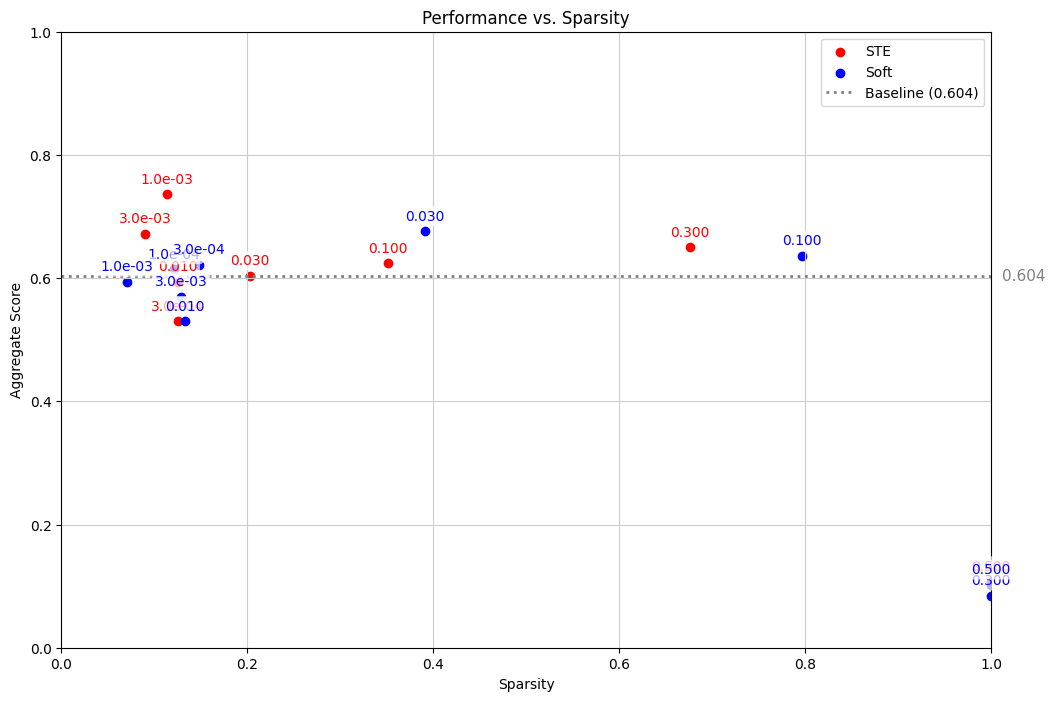

In [31]:
overlay_performance_vs_sparsity(
    dfs,
    labels=["STE", "Soft"],
    colors=["red", "blue"],
    baseline_row=baseline_df.iloc[0],
    xlim=(0, 1),
    ylim=(0, 1),
    title="Performance vs. Sparsity",
    xlabel="Sparsity",
    ylabel="Aggregate Score",
    legend_loc="best",
    output_path="scatter_token_level_gating.png",
    flip_x=False,
)

In [ ]:
from axbench.utils.data_utils import make_data_module
from axbench.utils.model_utils import get_prefix_length
import os
from torch.utils.data import DataLoader
from transformers import AutoTokenizer


def get_dataloader(dump_dir, df, tokenizer, batch_size=64):
    prefix_length = get_prefix_length(tokenizer)
    kwargs = {
        "prefix_length": prefix_length,
        "positions": "all",
        "exclude_bos": True,
        "metadata_path": os.path.join(dump_dir, "generate", "metadata.jsonl"),
    }
    teacher_data_module = make_data_module(tokenizer, df, **kwargs)
    dataloader = DataLoader(
        teacher_data_module["train_dataset"],
        batch_size=batch_size,
        shuffle=True,
        collate_fn=teacher_data_module["data_collator"],
    )
    return dataloader


base_df = pd.read_parquet(
    "../axbench/concept10/prod_2b_l20_v1/generate/train_data.parquet"
)
base_model = "google/gemma-2-2b-it"
tokenizer = AutoTokenizer.from_pretrained(
    base_model,
    model_max_length=512,
)
tokenizer.padding_side = "left"
dataloader = get_dataloader(
    "../axbench/concept10/prod_2b_l20_v1",
    base_df,
    tokenizer,
    batch_size=64,
)

In [ ]:
import matplotlib.pyplot as plt
import re
import numpy as np


def approx_sparsity_from_config(row):
    ipos = row.get("sparsity_coef", None)
    if isinstance(ipos, float) and np.isnan(ipos):
        return np.nan
    if ipos is None:
        return np.nan
    if not isinstance(ipos, str):
        return np.nan
    m = re.fullmatch(r"f(\d+)\+l(\d+)", ipos)
    if m:
        k1 = int(m.group(1))
        k2 = int(m.group(2))
        out = (k1 + k2) / seq_len
        return 1 - out
    m = re.fullmatch(r"s(\d+)", ipos)
    if m:
        k = int(m.group(1))
        out = 1 / k
        return 1 - out
    m = re.fullmatch(r"f(\d+)", ipos)
    if m:
        k = int(m.group(1))
        out = k / seq_len
        return 1 - out
    m = re.fullmatch(r"l(\d+)", ipos)
    if m:
        k = int(m.group(1))
        out = k / seq_len
        return 1 - out

    return np.nan


# For each unique sparsity_coef in the dataset, compute the average sparsity across the dataset
# using the per-example effective sequence length (sum of attention_mask for each example).
# The approx_sparsity_from_config function is used, but with the per-example seq_len.


def compute_avg_sparsity_per_coef(dataloader, sparsity_coefs):
    """
    For each sparsity_coef, compute the average sparsity across the dataset
    using per-example effective sequence length.

    Args:
        dataloader: DataLoader yielding batches with 'input_ids' and 'attention_mask'.
        sparsity_coefs: list of unique sparsity_coef values (as strings, e.g. "f8", "l16", ...)

    Returns:
        dict mapping sparsity_coef -> average sparsity (float)
    """
    avg_sparsity_per_coef = {}
    for coef in sparsity_coefs:
        total_sparsity = 0.0
        total_examples = 0
        for batch in dataloader:
            attn_mask = batch["attention_mask"].detach().cpu().numpy()
            batch_size = attn_mask.shape[0]
            effective_seq_lens = attn_mask.sum(axis=1)  # shape: (batch_size,)
            # For each example in the batch, compute approx_sparsity_from_config with this coef and its seq_len
            for seq_len in effective_seq_lens:
                # Patch the global seq_len for the function
                global_seq_len = globals().get("seq_len", None)
                globals()["seq_len"] = seq_len
                s = approx_sparsity_from_config({"sparsity_coef": coef})
                if not np.isnan(s):
                    total_sparsity += s
                    total_examples += 1
                if global_seq_len is not None:
                    globals()["seq_len"] = global_seq_len
        avg = total_sparsity / total_examples if total_examples > 0 else np.nan
        avg_sparsity_per_coef[coef] = avg
    return avg_sparsity_per_coef


# Example usage:
# Suppose you have a DataFrame df with a "sparsity_coef" column:
# unique_coefs = sorted(df["sparsity_coef"].dropna().unique())
# avg_sparsity_dict = compute_avg_sparsity_per_coef(dataloader, unique_coefs)
# print(avg_sparsity_dict)


entity = entity_name
project = project_name
groups = ["prefix_sweep", "prefix_suffix_sweep", "skip_sweep"]
labels = ["Prefix Sweep", "Prefix+Suffix Sweep", "Skip Sweep"]

# Use more muted, less saturated colors for better visibility
colors = ["#4C72B0", "#55A868", "#C44E52"]  # blue, green, red (colorblind friendly)

seq_len = 256

# Preprocess dfs to add approx_sparsity and sort, using compute_avg_sparsity_per_coef if possible
for i, df in enumerate(dfs):
    if "sparsity_coef" in df.columns:
        # If you have a dataloader for this sweep, use compute_avg_sparsity_per_coef
        if "dataloader" in locals() and dataloader is not None:
            unique_coefs = sorted(df["sparsity_coef"].dropna().unique())
            avg_sparsity_dict = compute_avg_sparsity_per_coef(dataloader, unique_coefs)
            # Map the avg sparsity back to the rows by coef
            df["approx_sparsity"] = df["sparsity_coef"].map(avg_sparsity_dict)
        else:
            df["approx_sparsity"] = df.apply(approx_sparsity_from_config, axis=1)
        df.sort_values("approx_sparsity", inplace=True)
    elif "sparsity" in df.columns:
        df["approx_sparsity"] = df["sparsity"]
        df.sort_values("approx_sparsity", inplace=True)
    else:
        df["approx_sparsity"] = np.nan
    dfs[i] = df  # update in place

import matplotlib.pyplot as plt
import numpy as np

# plt.style.use('seaborn-v0_8-muted')
plt.style.use("default")
colors = ["#4C72B0", "#55A868", "#C44E52"]
labels = ["Prefix Sweep", "Prefix+Suffix Sweep", "Skip Sweep"]
min_sparsity = 1e-3

# --------- 1. Full-range plot ---------
fig, ax = plt.subplots(figsize=(10, 6))
for df, color, label in zip(dfs, colors, labels):
    x = df["approx_sparsity"].clip(lower=min_sparsity, upper=1)
    y = df["aggregate_score"] if "aggregate_score" in df.columns else df.iloc[:, -1]
    mask = (~np.isnan(x)) & (~np.isnan(y))
    ax.scatter(
        x[mask],
        y[mask],
        color=color,
        label=label,
        s=50,
        edgecolor="gray",
        alpha=0.7,
        zorder=3,
    )
    ax.plot(x[mask], y[mask], color=color, alpha=0.8, linewidth=2, zorder=2)
    # Annotate every point
    if "sparsity_coef" in df.columns:
        for xi, yi, coef in zip(x[mask], y[mask], df["sparsity_coef"][mask]):
            ax.annotate(
                str(coef),
                (xi, yi),
                textcoords="offset points",
                xytext=(0, 8),
                ha="center",
                fontsize=9,
                color=color,
                alpha=0.9,
                bbox=dict(
                    boxstyle="round,pad=0.15", fc="white", ec=color, lw=0.5, alpha=0.5
                ),
            )
    else:
        for xi, yi, coef in zip(x[mask], y[mask], df["approx_sparsity"][mask]):
            ax.annotate(
                f"{coef:.3f}",
                (xi, yi),
                textcoords="offset points",
                xytext=(0, 8),
                ha="center",
                fontsize=9,
                color=color,
                alpha=0.9,
                bbox=dict(
                    boxstyle="round,pad=0.15", fc="white", ec=color, lw=0.5, alpha=0.5
                ),
            )

# Overlay the baseline as a dotted horizontal line in grey and label the value
if (
    "baseline_df" in locals()
    and baseline_df is not None
    and "aggregate_score" in baseline_df.columns
):
    baseline_score = baseline_df.iloc[0]["aggregate_score"]
    ax.axhline(
        baseline_score,
        color="grey",
        linestyle=":",
        linewidth=2,
        label=f"Baseline ({baseline_score:.3f})",
        zorder=1,
    )
    # Optionally, label the value on the right
    ax.text(
        1.01,
        baseline_score,
        f"{baseline_score:.3f}",
        color="grey",
        va="center",
        ha="left",
        fontsize=11,
        fontweight="bold",
        alpha=0.8,
        transform=ax.get_yaxis_transform(),
    )
elif "baseline_df" in locals() and baseline_df is not None and baseline_df.shape[1] > 0:
    baseline_score = baseline_df.iloc[0, -1]
    ax.axhline(
        baseline_score,
        color="grey",
        linestyle=":",
        linewidth=2,
        label=f"Baseline ({baseline_score:.3f})",
        zorder=1,
    )
    ax.text(
        1.01,
        baseline_score,
        f"{baseline_score:.3f}",
        color="grey",
        va="center",
        ha="left",
        fontsize=11,
        fontweight="bold",
        alpha=0.8,
        transform=ax.get_yaxis_transform(),
    )

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel("Sparsity", fontsize=13)
ax.set_ylabel("Aggregate Score", fontsize=13)
ax.set_title("Performance vs. Sparsity", fontsize=15)
ax.legend(loc="best", fontsize=12, frameon=True)
plt.tight_layout()
plt.show()

# --------- 2. Zoomed-in plot (high sparsity) ---------
fig, ax = plt.subplots(figsize=(10, 6))
for df, color, label in zip(dfs, colors, labels):
    x = df["approx_sparsity"].clip(lower=min_sparsity, upper=1)
    y = df["aggregate_score"] if "aggregate_score" in df.columns else df.iloc[:, -1]
    mask = (~np.isnan(x)) & (~np.isnan(y)) & (x >= 0.90)
    ax.scatter(
        x[mask],
        y[mask],
        color=color,
        label=label,
        s=50,
        edgecolor="gray",
        alpha=0.7,
        zorder=3,
    )
    ax.plot(x[mask], y[mask], color=color, alpha=0.8, linewidth=2, zorder=2)
    # Annotate every point
    if "sparsity_coef" in df.columns:
        for xi, yi, coef in zip(x[mask], y[mask], df["sparsity_coef"][mask]):
            ax.annotate(
                str(coef),
                (xi, yi),
                textcoords="offset points",
                xytext=(0, 8),
                ha="center",
                fontsize=9,
                color=color,
                alpha=0.9,
                bbox=dict(
                    boxstyle="round,pad=0.15", fc="white", ec=color, lw=0.5, alpha=0.5
                ),
            )
    else:
        for xi, yi, coef in zip(x[mask], y[mask], df["approx_sparsity"][mask]):
            ax.annotate(
                f"{coef:.3f}",
                (xi, yi),
                textcoords="offset points",
                xytext=(0, 8),
                ha="center",
                fontsize=9,
                color=color,
                alpha=0.9,
                bbox=dict(
                    boxstyle="round,pad=0.15", fc="white", ec=color, lw=0.5, alpha=0.5
                ),
            )

# Overlay the baseline as a dotted horizontal line in grey and label the value
if (
    "baseline_df" in locals()
    and baseline_df is not None
    and "aggregate_score" in baseline_df.columns
):
    baseline_score = baseline_df.iloc[0]["aggregate_score"]
    ax.axhline(
        baseline_score,
        color="grey",
        linestyle=":",
        linewidth=2,
        label=f"Baseline ({baseline_score:.3f})",
        zorder=1,
    )
    ax.text(
        1.01,
        baseline_score,
        f"{baseline_score:.3f}",
        color="grey",
        va="center",
        ha="left",
        fontsize=11,
        fontweight="bold",
        alpha=0.8,
        transform=ax.get_yaxis_transform(),
    )
elif "baseline_df" in locals() and baseline_df is not None and baseline_df.shape[1] > 0:
    baseline_score = baseline_df.iloc[0, -1]
    ax.axhline(
        baseline_score,
        color="grey",
        linestyle=":",
        linewidth=2,
        label=f"Baseline ({baseline_score:.3f})",
        zorder=1,
    )
    ax.text(
        1.01,
        baseline_score,
        f"{baseline_score:.3f}",
        color="grey",
        va="center",
        ha="left",
        fontsize=11,
        fontweight="bold",
        alpha=0.8,
        transform=ax.get_yaxis_transform(),
    )

ax.set_xlim(0.90, 1.00)
ax.set_ylim(0, 1)
ax.set_xticks([0.90, 0.92, 0.94, 0.96, 0.98, 1.00])
ax.set_xticklabels(
    [f"{s:.2f}" for s in [0.90, 0.92, 0.94, 0.96, 0.98, 1.00]], rotation=45
)
ax.set_xlabel("Sparsity (high)", fontsize=13)
ax.set_ylabel("Aggregate Score", fontsize=13)
ax.set_title("Performance vs. Sparsity (High Sparsity Zoom)", fontsize=15)
ax.legend(loc="best", fontsize=12, frameon=True)
plt.tight_layout()
plt.show()
